In [4]:
!pip install numpy PyMUST scipy matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [5]:
import scipy.signal as sp
import scipy.fft as spfft
import numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import pymust

In [6]:
c0 = 1540
f0 = 6e6
wavelength = c0 / f0

pitch = wavelength/2
max_pitch = 385e-6 # pitch of 2MHz array
COLUMNS = 40
ROWS = 40
kerf = 25e-6

print(fr"Pitch ($\lambda/2$) = {pitch/1e-6:.2f} um")

Pitch ($\lambda/2$) = 128.33 um


In [7]:
APERTURE_X = COLUMNS * max_pitch - kerf
APERTURE_Y = ROWS * max_pitch - kerf
depth = 5e-2

# define grid
Dx = APERTURE_X * 1.5
Dy = APERTURE_Y * 1.5
Dz = depth*1.2

dx = dy = dz = wavelength / 7

Nx = int(Dx / dx) + 1 # Azimutal dir.
Nz = int(Dy / dy) + 1 # Longitudinal dir.
Ny = int(Dz / dz) + 1 # Elevational dir.

x_extent = np.linspace(-Dx/2,Dx/2,Nx)
z_extent = np.linspace(0,Dz,Nz)
xi,zi = np.meshgrid(x_extent, z_extent);

# considering elevational focus, setup the elevational grid plane
yi = np.zeros(xi.shape)

In [8]:
def rgb2gray(rgb):
  r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
  gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
  return gray

In [9]:
# generate round fully reflective and fully absorving scatterers with varying diameter
MAX_DIAMETER = 8e-3 # 9 mm
MIN_DIAMETER = 1e-3 # 2 mm
COLUMN_SPACING = 0.725e-3 # 10 mm
NUM_SCATTER = 5

fc = 10 * f0 # 10 * Center Frequency at least
xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/fc)
RC = 0.1 * RC

In [10]:
def draw_circumference_scatter(xs, zs, rc, precision, diameter, center, rcval):
  ngrid = depth / precision
  mask = (xs - center[0])**2 + (zs-center[1])**2 <= (diameter**2) / 4
  assert rcval <= 1.0 or rcval >= 0.0, "RC value must be between 0 and 1"
  rc[mask] = rcval
  return rc

# draw increasing hole scatterers
startx = -MAX_DIAMETER
centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
startz = MAX_DIAMETER * 1.5
centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)

for k, cz in enumerate(centerz):
  RC = draw_circumference_scatter(xs, zs, RC, c0/fc, diameters[k], (centerx[0], cz), np.min(RC))

for k, cz in enumerate(centerz[::-1]):
  RC = draw_circumference_scatter(xs, zs, RC, c0/fc, diameters[k], (centerx[1], cz), np.max(RC))

# region without echoes / reflectionless (blood vessels)
anechoic_roi = np.zeros(xi.shape)

# region with maximal echo / reflection (bones, nerves)
hyperechoic_roi = np.zeros(xi.shape)

for k, cz in enumerate(centerz):
  mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
  anechoic_roi[mask] = 1

for k, cz in enumerate(centerz[::-1]):
  mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
  hyperechoic_roi[mask] = 1

Text(0, 0.5, 'z (m)')

Error in callback <function _draw_all_if_interactive at 0x1187d0ca0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

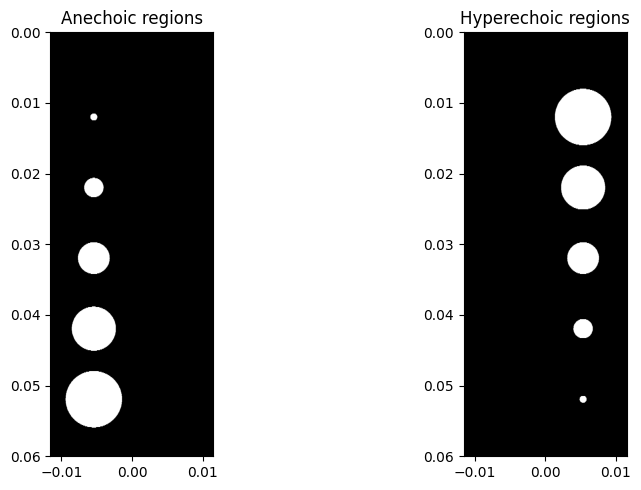

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(anechoic_roi, cmap='gray', extent = [xi[0,0], xi[-1,0-1], zi[-1,-1], zi[0,0]])
ax[0].set_title('Anechoic regions')
ax[1].imshow(hyperechoic_roi, cmap='gray', extent = [xi[0,0], xi[-1,0-1], zi[-1,-1], zi[0,0]])
ax[1].set_title('Hyperechoic regions')
fig.tight_layout()

plt.figure(figsize=(5,10))
plt.scatter(xs, zs, s = .2, c = np.abs(RC)**0.25, cmap ='gray')
plt.ylim(0, Dz)
plt.xlim(-Dx/2, Dx/2)
plt.grid(True)
plt.xlabel('x (m)')
plt.ylabel('z (m)')

In [ ]:
# Setup 2D sparse array
param = pymust.utils.Param()
param.fc = f0
param.kerf = 25e-06 # 50 um kerf
param.pitch = pitch
param.width = pitch - param.kerf
param.height = APERTURE_Y - param.kerf
param.Nelements = COLUMNS

#BW = 300.0e3
#param.bandwidth = 100*(BW/ param.fc) # percentage
param.bandwidth = 70
param.radius = np.inf

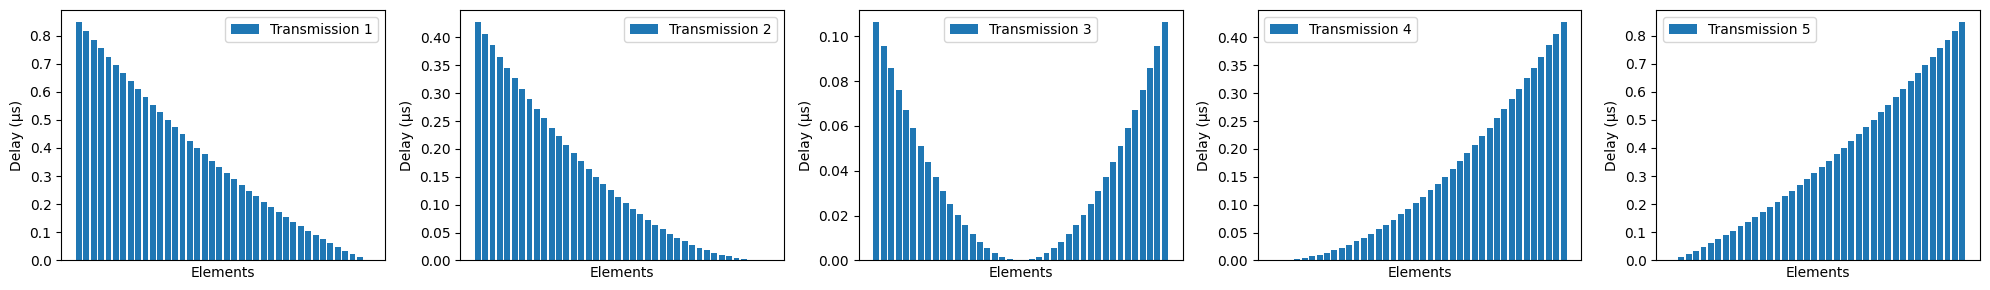

In [ ]:
#param.focus = 4.0e-2

# Observe 2D Transmission Profiles

MAX_ANGLE = 15.0 # 10.0
MIN_ANGLE = -15.0 # -10.0
NUM_PLANAR_WAVES = 5
tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
#tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
width = 15/180*np.pi # Diverging wave width with 30 degrees
txdel = []
for t in tilt:
    txdel.append(pymust.txdelay(param, t, width))
txdel_planar = np.array(txdel)

fig, ax = plt.subplots(1,len(txdel_planar), figsize=(20,3))
elemts = np.arange(param.Nelements)
#ax[0,1].bar(elemts, txdel_planar[-1][0,:]/1e-6, label='Transmission #7')
#ax[1,0].bar(elemts, txdel_planar[4][0,:]/1e-6, label='Transmission #5')
#ax[1,1].bar(elemts, txdel_planar[2][0,:]/1e-6, label='Transmission #3')
# remove axis
for i, a in enumerate(ax.flatten()):
    a.bar(elemts, txdel_planar[i][0,:]/1e-6, label=f'Transmission {i+1}')
    a.set_xticks([])
    a.set_xticklabels([])
    a.set_xlabel('Elements')
    a.set_ylabel('Delay (µs)')
    a.legend()
fig.tight_layout()

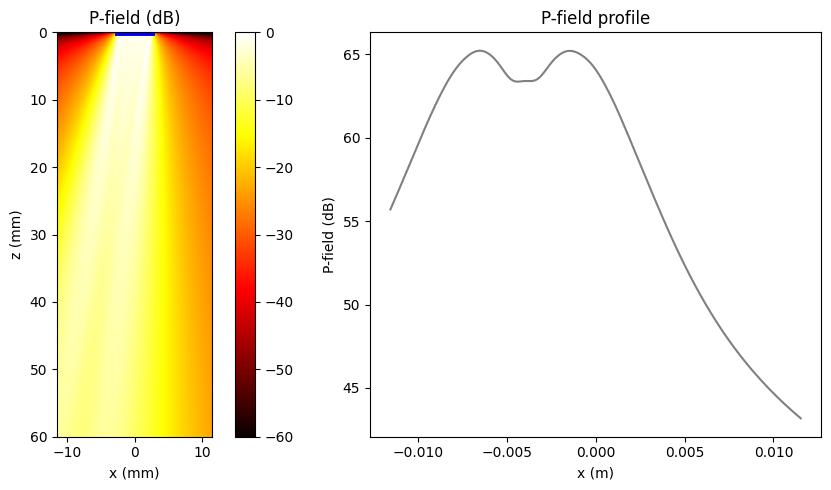

In [ ]:
## Observe the trasnmitted pressure field

angle_idx = 1
txdel = txdel_planar[angle_idx]
P, _, _ = pymust.pfield(xi,yi,zi,txdel,param)

fig, ax = plt.subplots(1,2, figsize=(10,5))

# Get the profile of the beam along hald depth
Pprofile = P[int(Nz/2),::4]
im1 = ax[1].plot(xi[0,::4],20 * np.log10(Pprofile), color='gray')
ax[1].set_xlabel('x (m)')
ax[1].set_ylabel('P-field (dB)')
ax[1].set_title('P-field profile')

# Get the sonicated medium
xe, ze, _, _ = param.getElementPositions()
ax[0].plot(xe.flatten()*1e3,ze.flatten()*1e3, linewidth = 5, c = 'b');
im2 = ax[0].imshow(20 * np.log10(P / np.max(P)), cmap='hot', extent = np.array([xi[0,0], xi[-1,0-1], zi[-1,-1], zi[0,0]])*1e3)
fig.colorbar(im2, ax=ax[0])
im2.set_clim(-60, 0)  # Set color scale here
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel('z (mm)')
ax[0].set_title(f'P-field (dB)')

fig.tight_layout()

In [ ]:
from pathlib import Path
dir = Path('./').resolve()
dir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/writting/DataAndSOTA/tcasi_journal')

In [ ]:
## Obtain golden-standard image to enable image quality metric (IQM) comparison with the remainder of the images

def boxcar_averager(data, param, order=2):
    """
    Smoothes an N x K matrix along the N axis (rows)
    independently for each of the K columns.
    """
    
    from scipy.signal import butter, lfilter, firwin
    from scipy.interpolate import interp1d
    #fmax = self.param.fc * (0.5*self.param.bandwidth/100 + 1.0)
    cutoff = 2*param.fc
    nyquist = 0.5 * param.fs
    Wn = cutoff/nyquist
    h = firwin(order, Wn, window='boxcar')
    return lfilter(h, 1.0, data)

class IdelAFE():
  def __init__(self, param):
    self.param = param

  def __call__(self, RF):
    RF_tgc, _ = pymust.tgc(RF)
    IQ = pymust.rf2iq(RF_tgc/np.max(np.abs(RF_tgc)),self.param.fs,self.param.fc)
    IQ = boxcar_averager(IQ, param)
    return IQ, RF_tgc

# 1. Gather the time signals for each modeled array

In [ ]:
RUN_RF_SIMULATIONS = False
ROWS = 40
COLUMNS = 40
KERF = 25e-6

MAX_ANGLE = 15.0 # 10.0
MIN_ANGLE = -15.0 # -10.0
NUM_PLANAR_WAVES = 5
DIVERGENT_ANGLE = 15.0

f0_settings = np.array([2.0, 2.5, 4.0, 6.0])*1e6

In [ ]:
if RUN_RF_SIMULATIONS:
  for f0_setting in f0_settings:
    
    # Setup 2D array parameters:
    param = pymust.utils.Param()
    param.fc = f0_setting
    wavelength = c0 / f0_setting
    pitch = wavelength / 2
    param.kerf = KERF
    param.pitch = pitch
    param.width = pitch - param.kerf
    param.height = ROWS * pitch - param.kerf
    param.Nelements = COLUMNS
    param.bandwidth = 70
    param.radius = np.inf
    
    param.fs = 4*param.fc
    param.attenuation = 0.5
    
    # Setup the transmit events
    tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
    width = DIVERGENT_ANGLE/180*np.pi # Diverging wave width with 30 degrees
    txdel = []
    for t in tilt:
        txdel.append(pymust.txdelay(param, t, width))
    txdel_planar = np.array(txdel)    
    np.save(dir / f'txdelays_f0_setting_{f0_setting/1e6:.2f}_mhz.npy', txdel_planar)
    
    # Simulate and setup the raw RF ultrasound data
    RF = [0]*len(txdel_planar)
    for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
      RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
    # Save the raw RF data
    for transmit_event, r in enumerate(RF):
      np.save(dir / f"us_raw_rf_f0_setting_{f0_setting/1e6:.2f}_mhz_tx_event_{transmit_event}.npy", r)

# 2. Setup to the AFE Evaluation Scheduler

In [ ]:
#from typing import NamedTuple
from dataclasses import dataclass, asdict
@dataclass
class AFEConfig:
  snr: float = np.inf # dB
  hd2: float = np.inf # dB
  hd3: float = np.inf # dB
  gain_range: float = 40 # dB
  psrr: float = np.inf # dB
  gain_err: float = 0.0 #dB
  linear_dynamic_range: float = np.inf #dB
  bw: float = 0.49 # bandwidth multiplifer relative to transducer Fs
  # in this design the bandwidth
  #fs: float = 4.0 # sampling frequency multiplifer relative to transducer Fc
  discrete: bool = False
  gain_steps: int = 1000
  sub_array_size: int = 1
  filter_order: int = 2
  jitter_std: float = 0.0 # s
  settling: float = 10 # Ts / boxcar_tap_settling
  max_input_range: float = 1.0 # 0.45 Volt
  supply: float = 1.8 # V
  
  def __setitem__(self, key, value):
    # Check if the attribute exists to prevent adding random keys
    if hasattr(self, key):
        setattr(self, key, value)
    else:
        raise KeyError(f"'{key}' is not a valid parameter in FilterParams")

  def __getitem__(self, key):
    return getattr(self, key)
  
  def default(self):
    targets = ['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err']
    return {key:asdict(self)[key] for key in targets}

In [ ]:


class AFE():
  def __init__(self, param, afe_cfg: AFEConfig):
    self.param = param
    self.cfg = afe_cfg

  def _add_noise(self, r):
    irn_rms = self.cfg.max_input_range / 10**(self.cfg.snr/20)
    noise = np.random.normal(0, irn_rms/np.sqrt(self.cfg.sub_array_size), r.shape)
    return r + noise

  def _add_psrr_induced_noise(self, r):
    psrr_irn = self.cfg.supply / 10**(self.cfg.psrr / 20)
    psrr_irn = psrr_irn / np.sqrt(self.cfg.sub_array_size)
    noise = np.random.normal(0, psrr_irn, r.shape)
    return r + noise

  def _add_distortion(self, r):
    r2 = np.square(r)
    r3 = np.power(r, 3)
    hd2_amplitude = 10 ** (-self.cfg.hd2 / 20)
    hd3_amplitude = 10 ** (-self.cfg.hd3 / 20)

    return r + hd2_amplitude * r2 + hd3_amplitude * r3

  def _filter(self, r):
    # this function applies the zero-order sample and hold filtering within the system
    from scipy.signal import butter, lfilter, firwin
    from scipy.interpolate import interp1d
    #fmax = self.param.fc * (0.5*self.param.bandwidth/100 + 1.0)
    cutoff = self.param.fs * self.cfg.bw
    nyq = self.param.fs * .5
    fc = cutoff / nyq

    num_taps = self.cfg.filter_order # 2 taps
    h = firwin(num_taps, fc, window='boxcar')
    y =  lfilter(h, 1.0, r)
    """
    b, a = butter(
        self.cfg.filter_order,
        cutoff*2*np.pi,
        btype='low', analog=True,
    )
    y =  lfilter(b, a, r)
    """
    # apply clock jitter to the sampled signal
    for k, rf in enumerate(y):
      t = np.arange(0, np.max(rf.shape))/self.param.fs
      t_jittered = t + np.random.normal(0, self.cfg.jitter_std, size=t.shape)
      rf_interp = interp1d(t, rf, kind='linear', fill_value="extrapolate")
      y[k] = rf_interp(t_jittered)


    # apply skew
    y = y * (1 - np.exp(-self.cfg.settling))

    # apply further digital filtering off chip
    #num_taps = 8
    #h = firwin(num_taps, fc, window='nuttall')
    #y = lfilter(h, 1.0, y)

    return y

  def _tgc(self, r):
    y = np.zeros_like(r)
    if self.cfg.discrete:
      tgc_settings = np.linspace(0.0, self.cfg.gain_range, num=int(self.cfg.gain_steps)) + self.cfg.gain_err * (np.random.random(size = int(self.cfg.gain_steps))*2.0 - 1.0)
      seps = int(np.ceil(max(r.shape) / len(tgc_settings)))
      for i in range(len(tgc_settings)):
        y[seps*i:seps*(i+1)] = r[seps*i:seps*(i+1)]*(10**(tgc_settings[i]/20.0))
    else:
      len_rf = max(r.shape)
      av = 10**((self.cfg.gain_range/20)*np.arange(len_rf)/len_rf)
      y = av[:, np.newaxis] * r
    #return y
    #y, _ = must.tgc(r)
    return y

  def __call__(self, r):
    y = self._tgc(self._filter(self._add_distortion(self._add_psrr_induced_noise(self._add_noise(r)))))
    # account for linear dynamic range in the input to output power TF
    #vmin = np.min(y[y!=0])
    #vmax = vmin * 10 ** (self.cfg.linear_dynamic_range / 20)
    #y[y>vmax] = vmax
    return y

Setup Monte-Carlo simulation:

In [ ]:
from collections import defaultdict

MC_NUM_POINTS = 10
class MonteCarloConfig():
    
    iterations: dict = {
        "snr": 20,
        "hd2": 20,
        "hd3": 20,
        "psrr": 20,
        "gain_err": 20,
        "gain_steps":1
    }
    current_iteration: int = 0
    parameters: dict = {
        "snr": np.linspace(0.0, 100.0, MC_NUM_POINTS)[::-1],
        "hd2": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        "hd3": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        #"linear_dynamic_range": np.linspace(0.0, 100, MC_NUM_POINTS),
        "psrr": np.linspace(0.0, 100, MC_NUM_POINTS)[::-1],
        #"sub_array_size": np.array(list(range(1, COLUMNS+1,))),
        "gain_steps": [1000] + list(range(2, MC_NUM_POINTS+1))[::-1],
        "gain_err": np.linspace(0, 6.0, num=MC_NUM_POINTS)
    }
    results = defaultdict(list)
    

Setup image quality evaluation metrics, based on:

Several image quality metrics exist. The ones being used are based on the same metrics used in [2,3].




[2] N. Radeljic-Jakic, A. J. Flikweert, N. N. M. Rozsa, H. J. Vos and M. A. P. Pertijs, "Using Image Quality Metrics to Optimize the Design of Integrated Medical Ultrasound ADCs," in IEEE Transactions on Ultrasonics, Ferroelectrics, and Frequency Control, doi: 10.1109/TUFFC.2025.3577258.

[3] M. Zhou, S. Ouzounov, M. Mischi, E. Cantatore and P. Harpe, "The Impact of Analog Front-end Filters on Ultrasound Harmonic Imaging," 2019 IEEE International Ultrasonics Symposium (IUS), Glasgow, UK, 2019, pp. 993-996, doi: 10.1109/ULTSYM.2019.8926057.


To measure the Contrast-to-Noise Ratio of the images, the generalized CNR measurement [5] is used.

[5] A. Rodriguez-Molares, O. M. Hoel Rindal, J. D'hooge, S. -E. Måsøy, A. Austeng and H. Torp, "The Generalized Contrast-to-Noise Ratio," 2018 IEEE International Ultrasonics Symposium (IUS), Kobe, Japan, 2018, pp. 1-4, doi: 10.1109/ULTSYM.2018.8580101.

In [ ]:
!pip install scikit-image

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
class ImageMetricEvaluator():
  golden_reference: np.ndarray = None
  anechoic_roi: np.ndarray = None
  hyperechoic_roi: np.ndarray = None
  def __init__(self, golden_reference, anechoic_roi, hyperechoic_roi):
    self.golden_reference = golden_reference
    self.anechoic_roi = anechoic_roi
    self.hyperechoic_roi = hyperechoic_roi
    self.golden_reference8b = (self.golden_reference * 255).astype(np.uint8)
    self.golden_reference8b = self.golden_reference8b.astype(np.float64)

  def _mse(self, I):
    I8b = (I * 255).astype(np.uint8)
    I8b = I8b.astype(np.float64)
    return np.mean((self.golden_reference8b - I8b)**2)

  def _psnr(self, I):
    mse = self._mse(I)
    return 20 * np.log10( 255 / np.sqrt(mse))

  def _ssim(self, I):
    from skimage.metrics import structural_similarity as ssim
    return ssim(self.golden_reference, I, data_range=self.golden_reference.max() - self.golden_reference.min())

  def _gcnr(self, I):
    # compute anechoic gCNR
    signal = anechoic_roi == 1.0
    background = anechoic_roi == 0.0
    aS = np.var(I[signal]) / np.var(I[background])

    agCNR = np.abs(aS**(-1/(aS - 1)) - aS**(-aS/(aS - 1)))

    # compute hyperechoic gCNR
    signal = hyperechoic_roi == 1.0
    background = hyperechoic_roi == 0.0
    hS = np.var(I[signal]) / np.var(I[background])

    hgCNR = np.abs(hS**(-1/(hS - 1)) - hS**(-hS/(hS - 1)))
    return agCNR, hgCNR

  def evaluate(self, I):
    return {
        "mse": self._mse(I),
        "psnr": self._psnr(I),
        "ssim": self._ssim(I),
        "gcnr": self._gcnr(I)
    }

Run Monte Carlo Simulation

In [ ]:
from pprint import pprint
RUN_MONTE_CARLO_AFE_EVAL = False
mc_cfg = MonteCarloConfig()
pprint(mc_cfg)

In [ ]:
afe_cfg = AFEConfig()
pprint(afe_cfg)
afe_cfg.default()

AFEConfig(snr=inf,
          hd2=inf,
          hd3=inf,
          gain_range=40,
          psrr=inf,
          gain_err=0.0,
          linear_dynamic_range=inf,
          bw=0.49,
          discrete=False,
          gain_steps=1000,
          sub_array_size=1,
          filter_order=2,
          jitter_std=0.0,
          settling=10,
          max_input_range=1.0,
          supply=1.8)


{'snr': inf,
 'hd2': inf,
 'hd3': inf,
 'gain_steps': 1000,
 'psrr': inf,
 'gain_err': 0.0}

In [ ]:
import json

RUN_MC_INTERNAL_LOOP = True
  
if RUN_MONTE_CARLO_AFE_EVAL:
  for f0_setting in f0_settings:
    mc_cfg.current_iteration = 1
    rf_data_file_pointer = dir / f"us_raw_rf_f0_setting_{f0_setting/1e6:.2f}_mhz"
    # Setup Ideal, golden standard image
    # Setup 2D array parameters:
    param = pymust.utils.Param()
    param.fc = f0_setting
    wavelength = c0 / f0_setting
    pitch = wavelength / 2
    param.kerf = KERF
    param.pitch = pitch
    param.width = pitch - param.kerf
    param.height = ROWS * pitch - param.kerf
    param.Nelements = COLUMNS
    param.bandwidth = 60
    param.radius = np.inf
    param.fs = 4*param.fc 
    param.attenuation = 0.5
    RF = []
    txdel_planar = np.load(dir / f'txdelays_f0_setting_{f0_setting/1e6:.2f}_mhz.npy')
    for transmit_event in range(len(txdel_planar)):
      RF.append(np.load(str(rf_data_file_pointer) + f'_tx_event_{transmit_event}.npy'))
      RF[-1] = RF[-1] / np.max(np.abs(RF[-1]))
    
    if RUN_MC_INTERNAL_LOOP:
      for parameter in tqdm.tqdm(mc_cfg.parameters):
        if f0_setting == 2e6:
          if parameter in ['snr', 'hd2', 'hd3', 'psrr']: continue
        print(f"Sweeping parameter: {parameter}")
        for idval, val in tqdm.tqdm(enumerate(mc_cfg.parameters[parameter])):
          for iter in tqdm.tqdm(range(mc_cfg.iterations[parameter])):
            afe_cfg = AFEConfig()
            afe_cfg.discrete = True
            if parameter != 'gain_steps':
              afe_cfg[parameter] = val + 0.05 * np.max(np.abs(mc_cfg.parameters[parameter])) * np.random.randn()
            else: afe_cfg[parameter] = val
            afe = AFE(param, afe_cfg)
            #tgc_settings = np.linspace(0.0, afe_cfg.gain_range, num=afe_cfg.gain_steps)
            
            RF_tgc = []
            for r in RF:
              RF_tgc.append(afe(r))
            IQ = []
            for r in RF_tgc:
              IQ.append(pymust.rf2iq(
                r/np.max(np.abs(r)),param.fs,param.fc))
            bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
            for k, t in enumerate(txdel_planar):
                param.TXdelay = t
                bIQ[:,:,k] = (pymust.dasmtx(
                  IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
            cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
            Imeas = pymust.bmode(cIQ,60); #log-compressed image
            if mc_cfg.current_iteration == 1:
              I = Imeas.copy()
              imq_evaluator = ImageMetricEvaluator(I, anechoic_roi, hyperechoic_roi)
              plt.imshow(I, cmap = 'gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
              plt.colorbar()
              plt.axis('equal')
              plt.ylabel('[cm]')
              plt.title('Compound PW-based echo image')
              plt.show()
            # Measure
            results_img_eval_raw = imq_evaluator.evaluate(Imeas)
            results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
            results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
            results_db_row = {'f0_mhz': f0_setting/1e6}
            results_db_row.update(afe_cfg.default())
            results_db_row.update(results_img_eval)
            if mc_cfg.current_iteration == 1:
              with open(dir / 'mc_results_afe_eval.csv', 'a') as fp:
                fp.write(','.join([k for k in results_db_row.keys()])+'\n')
            #print(results_db_row)
            with open(dir / 'mc_results_afe_eval.csv', 'a') as fp:
              fp.write(','.join([str(k) for k in results_db_row.values()])+'\n')
            mc_cfg.current_iteration += 1

## Img Quality vs. Analog Frontend Nonidealities Monte Carlo Results Evaluation

In [ ]:
!pip install SciencePlots seaborn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
import scienceplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use(['science', 'nature'])

In [ ]:
mcdf = pd.read_csv(dir / 'mc_results_afe_eval.csv')
print(len(mcdf))
mcdf.head()

4199


,f0_mhz,snr,hd2,hd3,gain_steps,psrr,gain_err,mse,psnr,ssim,a-gcnr,h-gcnr
0,2.0,93.029618,inf,inf,1000.0,inf,0.0,0.000000,inf,1.000000,0.157681,0.081623
1,2.0,97.508035,inf,inf,1000.0,inf,0.0,2.973276,43.398451,0.999928,0.157850,0.081623
2,2.0,99.305450,inf,inf,1000.0,inf,0.0,3.468986,42.728778,0.999931,0.157873,0.081624
3,2.0,91.900291,inf,inf,1000.0,inf,0.0,3.147942,43.150536,0.999907,0.158002,0.081706
4,2.0,92.300630,inf,inf,1000.0,inf,0.0,4.132337,41.968846,0.999905,0.157706,0.081553


In [ ]:
mcdf['gain_steps'] = mcdf['gain_steps'].apply(lambda val: int(val)) 

In [ ]:
xvars = list(mcdf.columns[1:7])
xvars

['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err']

In [ ]:
yvars = list(mcdf.columns[7:])
yvars

['mse', 'psnr', 'ssim', 'a-gcnr', 'h-gcnr']

In [ ]:
batch_size = 5
group_id = np.arange(len(mcdf)) // batch_size

for xvar in xvars:
    mcdf['mean_' + xvar] = mcdf.groupby(group_id)[xvar].transform('mean')

In [ ]:
mcdf.head()

,f0_mhz,snr,hd2,hd3,gain_steps,psrr,gain_err,mse,psnr,ssim,a-gcnr,h-gcnr,mean_snr,mean_hd2,mean_hd3,mean_gain_steps,mean_psrr,mean_gain_err
0,2.0,93.029618,inf,inf,1000,inf,0.0,0.000000,inf,1.000000,0.157681,0.081623,94.808805,inf,inf,1000.0,inf,0.0
1,2.0,97.508035,inf,inf,1000,inf,0.0,2.973276,43.398451,0.999928,0.157850,0.081623,94.808805,inf,inf,1000.0,inf,0.0
2,2.0,99.305450,inf,inf,1000,inf,0.0,3.468986,42.728778,0.999931,0.157873,0.081624,94.808805,inf,inf,1000.0,inf,0.0
3,2.0,91.900291,inf,inf,1000,inf,0.0,3.147942,43.150536,0.999907,0.158002,0.081706,94.808805,inf,inf,1000.0,inf,0.0
4,2.0,92.300630,inf,inf,1000,inf,0.0,4.132337,41.968846,0.999905,0.157706,0.081553,94.808805,inf,inf,1000.0,inf,0.0


/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_94620/3946616672.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10],
/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_94620/3946616672.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10],
/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_94620/3946616672.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10],
/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_94620/3946616672.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10],
/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_94620/3946616672.py:47: UserWarning: Boolean Series key w

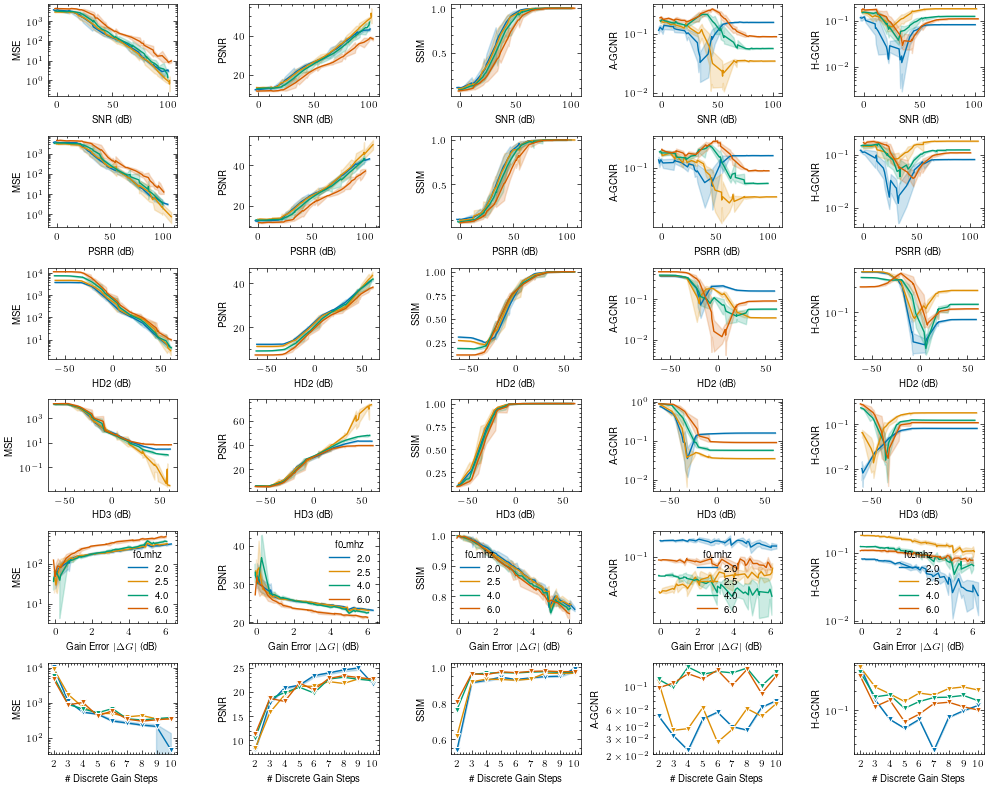

In [ ]:
fig, ax = plt.subplots(len(xvars),len(yvars), figsize=(10,8))

letters = [c for c in range(ord('a'),ord('z')+1)]

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['snr']<np.inf], x='mean_snr', y=yvar, ax=ax[0, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[0, yvars.index(yvar)].set_yscale('log')
    ax[0, yvars.index(yvar)].set_xlabel('SNR (dB)')
    ax[0, yvars.index(yvar)].set_ylabel(yvar.upper())
    
for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['psrr']<np.inf], x='mean_psrr', y=yvar, ax=ax[1, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[1, yvars.index(yvar)].set_yscale('log')
    ax[1, yvars.index(yvar)].set_xlabel('PSRR (dB)')
    ax[1, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['hd2']<np.inf], x='mean_hd2', y=yvar, ax=ax[2, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[2, yvars.index(yvar)].set_yscale('log')
    ax[2, yvars.index(yvar)].set_xlabel('HD2 (dB)')
    ax[2, yvars.index(yvar)].set_ylabel(yvar.upper())
    
for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['hd3']<np.inf], x='mean_hd3', y=yvar, ax=ax[3, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[3, yvars.index(yvar)].set_yscale('log')
    ax[3, yvars.index(yvar)].set_xlabel('HD3 (dB)')
    ax[3, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['gain_err']!=0.0], x='mean_gain_err', y=yvar, ax=ax[4, yvars.index(yvar)], hue='f0_mhz',legend=True,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[4, yvars.index(yvar)].set_yscale('log')
    ax[4, yvars.index(yvar)].set_xlabel('Gain Error $|\Delta G|$ (dB)')
    ax[4, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10], 
        x='gain_steps', 
        y=yvar, 
        ax=ax[5, yvars.index(yvar)], 
        hue='f0_mhz', 
        legend=False,
        palette='colorblind', 
        marker='v',
        markersize=5)
    if yvar not in ['ssim', 'psnr']:
        ax[5, yvars.index(yvar)].set_yscale('log')
    ax[5, yvars.index(yvar)].set_xlabel('\# Discrete Gain Steps')
    ax[5, yvars.index(yvar)].set_ylabel(yvar.upper())
    ax[5, yvars.index(yvar)].set_xticks(list(range(2,11)))

fig.tight_layout()
#fig.savefig(dir/'mc_results.pdf', dpi=300)

### Observe reference images for each frequency, against non idealities

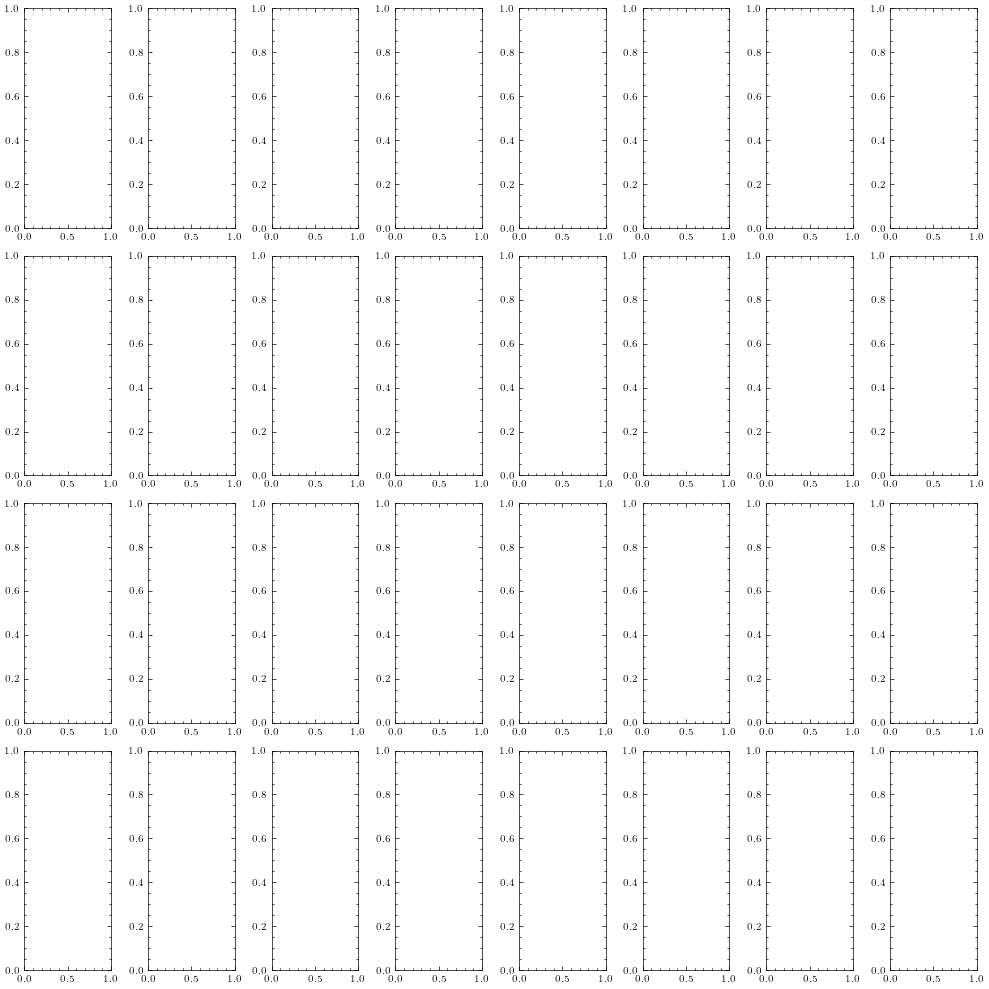

In [ ]:
img_sweep_config = {
    'snr': np.array([np.inf, -6, 0, 60]),
    'hd3': np.array([np.inf, -6, 0, 30]),
    'gain_steps': np.array([1000, 2, 4, 10]),
    'gain_err': np.array([0, 3, 6, 9]),
}
f0_to_plot = [2.0e6, 4.0e6]
fig, ax = plt.subplots(4, 8, figsize=(10,10))
RUN_MONTE_CARLO_IMG_SWEEP = False
if RUN_MONTE_CARLO_IMG_SWEEP:
    for n, f0_plot in enumerate(f0_to_plot):
        # Build simulation media
        # Setup 2D array parameters:
        param = pymust.utils.Param()
        param.fc = f0_plot
        wavelength = c0 / f0_plot
        pitch = wavelength / 2
        param.kerf = KERF
        param.pitch = pitch
        param.width = pitch - param.kerf
        param.height = ROWS * pitch - param.kerf
        param.Nelements = COLUMNS
        param.bandwidth = 70
        param.radius = np.inf
        
        param.fs = 4*param.fc
        param.attenuation = 0.5
        
        # Setup the simulation medium
        dx = dy = dz = wavelength / 10
        Nx = int(Dx / dx) + 1 # Azimutal dir.
        Nz = int(Dy / dy) + 1 # Longitudinal dir.
        Ny = int(Dz / dz) + 1 # Elevational dir.

        x_extent = np.linspace(-Dx/2,Dx/2,Nx)
        z_extent = np.linspace(0,Dz,Nz)
        xi,zi = np.meshgrid(x_extent, z_extent);
        yi = np.zeros(xi.shape)
        
        fc = 10 * param.fc # 10 * Center Frequency at least
        xs,ys,zs,RC = pymust.genscat(np.array([Dz, Dz*1.5]),c0/param.fc)
        RC = 0.1 * RC
        
        # Setup scatterer and hole location
        
        # draw increasing hole scatterers
        startx = -MAX_DIAMETER
        centerx = np.array([-MAX_DIAMETER/1.5, MAX_DIAMETER/1.5])
        startz = MAX_DIAMETER * 1.5
        centerz = np.linspace(startz, startz + NUM_SCATTER * (MAX_DIAMETER), NUM_SCATTER)
        diameters = np.linspace(MIN_DIAMETER, MAX_DIAMETER, NUM_SCATTER)

        for k, cz in enumerate(centerz):
            RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[0], cz), np.min(RC))

        for k, cz in enumerate(centerz[::-1]):
            RC = draw_circumference_scatter(xs, zs, RC, c0/param.fc, diameters[k], (centerx[1], cz), np.max(RC))

        # region without echoes / reflectionless (blood vessels)
        anechoic_roi = np.zeros(xi.shape)

        # region with maximal echo / reflection (bones, nerves)
        hyperechoic_roi = np.zeros(xi.shape)

        for k, cz in enumerate(centerz):
            mask = (xi - centerx[0])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
            anechoic_roi[mask] = 1

        for k, cz in enumerate(centerz[::-1]):
            mask = (xi - centerx[1])**2 + (zi-cz)**2 <= (diameters[k]/2)**2
            hyperechoic_roi[mask] = 1
        
        
        # Setup transmit events
        MAX_ANGLE = 15.0 # 10.0
        MIN_ANGLE = -15.0 # -10.0
        NUM_PLANAR_WAVES = 5
        tilt = np.linspace(MIN_ANGLE,MAX_ANGLE,NUM_PLANAR_WAVES)/180*np.pi; # tilt angles in rad
        #tilt = [MIN_ANGLE, 0.0, MAX_ANGLE]
        width = 15/180*np.pi # Diverging wave width with 30 degrees
        txdel = []
        for t in tilt:
            txdel.append(pymust.txdelay(param, t, width))
        txdel_planar = np.array(txdel)
        
        # Re-simulate RF channels
        RF = [0]*len(txdel_planar)
        for k, transmit_event in tqdm.tqdm(enumerate(txdel_planar)):
            RF[k], _ = pymust.simus(xs,zs,RC,txdel_planar[k], param)
            RF[k] = RF[k] / np.max(np.abs(RF[k]))
        
        #for transmit_event, r in enumerate(RF):
        #np.save(dir / f"us_raw_rf_f0_setting_{f0_setting/1e6:.2f}_mhz_tx_event_{transmit_event}_comparison_plots.npy", r)
        
        for j,par in enumerate(img_sweep_config.keys()):
            for i,val in enumerate(img_sweep_config[par]):
                afe_cfg = AFEConfig()
                afe_cfg.discrete = True
                afe_cfg[par] = val
                afe = AFE(param, afe_cfg)
                #tgc_settings = np.linspace(0.0, afe_cfg.gain_range, num=afe_cfg.gain_steps)
                
                RF_tgc = []
                for r in RF:
                #RF_tgc.append(np.clip(afe(r), -1.0, 1.0))
                    RF_tgc.append(afe(r))
                IQ = []
                for r in RF_tgc:
                    IQ.append(pymust.rf2iq(
                        r,param.fs,param.fc))
                bIQ = np.zeros((*xi.shape, len(txdel_planar)), dtype = np.complex64)  #% this array will contain the 21 I/Q images
                for k, t in enumerate(txdel_planar):
                    param.TXdelay = t
                    bIQ[:,:,k] = (pymust.dasmtx(
                    IQ[k], xi,zi, param) @ IQ[k].flatten(order = 'F')).reshape(xi.shape,order = 'F')
                cIQ = np.sum(bIQ,2) # this is the compound beamformed I/Q
                I = pymust.bmode(cIQ,60); #log-compressed image
                ax[j,i + n*4].imshow(I, cmap = 'gist_gray', extent = [xi[0,0], xi[0,-1], zi[0,0], zi[-1,-1]])
                #ax[j,i].set_axis('equal')
                ax[j, i + n*4].set_yticks([])
                ax[j, i + n*4].set_xticks([])
                #ax[j, i + n*4].set_yticks([zi[0,0], zi[0,-1]])
                #ax[j, i + n*4].set_xticks([xi[0,0], xi[0,-1]])
                #ax[j, i + n*4].set_yticklabels([round(zi[0,0]/1e-3, 1), round(zi[0,-1]/1e-3, 1)])
                #ax[j, i + n*4].set_xticklabels([round(xi[0,0]/1e-3,1), round(xi[0,-1]/1e-3,1)])
                #ax[j,i].set_xlabel('mm')
                #ax[j,i].set_ylabel('mm')
            
fig.tight_layout()
fig.savefig(dir/'comparison_monte_carlo.pdf', dpi=300)

In [ ]:
fig.savefig(dir/'comparison_monte_carlo.pdf', dpi=300)

# 3. Study of Color Doppler Imaging Quality vs. Analog Frontend Non-Idealities

In [22]:
import numpy as np, matplotlib.pyplot as plt, pymust
import tqdm, tqdm.notebook
import os

## 3.1 Setup Rotating Disk for Setup Evaluation

Based on "Functional ultrasound imaging of the brain", https://www.nature.com/articles/nmeth.1641, blood velocity in 

1. capillaries can go up to < 1 mm / s
2. arteries can reach several centimeters p/ sec < 10 cm / s

In [23]:
class MyOptions(pymust.utils.Options):
    def copy(self):
        p = MyOptions()
        for k in self.keys():
            p[k] = self[k]
        return p

In [24]:
c0 = 1540 # m/s
f0 = 2.5e6 # Hz
wavelength = c0 / f0
pitch = wavelength / 2

max_pitch = 385e-6 # pitch of 2MHz array
COLUMNS = 40
ROWS = 40
kerf = 25e-6
APERTURE_X = COLUMNS * max_pitch - kerf
APERTURE_Y = ROWS * max_pitch - kerf
depth = 5e-2

In [25]:
APERTURE_X = COLUMNS * max_pitch - kerf
APERTURE_Y = ROWS * max_pitch - kerf
depth = 5e-2

# define grid
Dx = APERTURE_X * 1.5
Dy = APERTURE_Y * 1.5
Dz = depth*1.2

dx = dy = dz = wavelength / 10

Nx = int(Dx / dx) + 1 # Azimutal dir.
Nz = int(Dy / dy) + 1 # Longitudinal dir.
Ny = int(Dz / dz) + 1 # Elevational dir.

x_extent = np.linspace(-Dx/2,Dx/2,Nx)
z_extent = np.linspace(0,Dz,Nz)
xi,zi = np.meshgrid(x_extent, z_extent);

# considering elevational focus, setup the elevational grid plane
yi = np.zeros(xi.shape)

In [26]:
# Setup 2D sparse array
param = pymust.utils.Param()
param.fc = f0
param.kerf = 25e-06 # 50 um kerf
param.pitch = pitch
param.width = pitch - param.kerf
param.height = APERTURE_Y - param.kerf
param.Nelements = COLUMNS

#BW = 300.0e3
#param.bandwidth = 100*(BW/ param.fc) # percentage
param.bandwidth = 70
param.radius = np.inf

In [27]:
small_test = True # Turn it to true if your computer has problems computing
#param = pymust.getparam('L11-5v')
param.TXnow = 10

nPoints = 500000 if not small_test else 50000
xs = np.random.rand(1,nPoints)*APERTURE_X - APERTURE_X / 2
zs = np.random.rand(1,nPoints)*APERTURE_X

centerDisk = APERTURE_X / 2
idx = np.hypot(xs,zs-centerDisk)<3e-3 # First disk
#idx2 = np.hypot(xs,zs-.035)< 5e-3 # Second disk, smaller with high intensity

RC = np.random.rand(*xs.shape)  # reflection coefficients

# Add reflectiion to both spheres
RC[idx] += .5
#RC[idx2] += 2

# Rotating disk velocity
rotation_frequency = 1 # Hz
w = 2 * np.pi  * rotation_frequency#1 Hz = 2 pi rads
nreps = 3
PRF = 1e3 # at least 200 Hz, for nyquist sampling of rotation
param.PRP = 1 / PRF

In [28]:
def rotatePoints(x, y, x0, y0, theta):
    """
    Rotate points (x,y) around (x0,y0) by theta radians
    """
    x = x - x0
    y = y - y0
    x1 = x * np.cos(theta) - y * np.sin(theta) + x0
    y1 = x * np.sin(theta) + y * np.cos(theta) + y0
    return x1, y1

In [29]:
options =  MyOptions()
options.ParPoolMode = 'thread'
options.ParPool_NumWorkers = 12
options.dBThresh = -6
options.ParPool = os.name == 'posix' # Only activate parallelism in mac / linux. Set this to True if you want to try it in windows

In [30]:
width = 10/180*np.pi; # width angle in rad
txdel = pymust.txdelay(param, 0 ,width) # in s
RF_ref, RF_spectrum = pymust.simus(xs,zs,RC,txdel,param, options) # Remove options if it does not work
rotationAngle = 10 #rotate 0 rad (absolute) ; you will need to modify this
xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  rotationAngle) #Rotate the disk a certain amount, this should 
RF_rotated, RF_spectrum = pymust.simus(xs,zs,RC,txdel,param, options) # Remove options if it does not work

In [31]:
IQ = np.zeros([RF_ref.shape[0], RF_ref.shape[1], 2], dtype = np.complex128)
IQ[:, :, 0] = pymust.rf2iq(RF_ref,param)
IQ[:, :, 1] = pymust.rf2iq(RF_rotated,param)[:IQ.shape[0], :]

# Num points
dx = dz = wavelength / 10
Nx = int(APERTURE_X / dx)
Nz = int(APERTURE_X / dz)
x_extent = np.linspace(-APERTURE_X/2, APERTURE_X/2, Nx)
z_extent = np.linspace(0, APERTURE_X, Nz)
xi,zi = np.meshgrid(x_extent, z_extent)

#x,z = pymust.impolgrid(np.array([Nx, Nz], dtype = np.int64),APERTURE_X, np.pi/2, param)
Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
IQb = np.zeros((xi.shape[0], xi.shape[1],2), dtype = np.complex128)
bmodes = np.zeros((xi.shape[0], xi.shape[1], 2), dtype = np.float32)

for i in tqdm.tqdm(range(2)):
    IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
    bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])
   

100%|██████████| 2/2 [00:00<00:00, 57.29it/s]


[None, None]

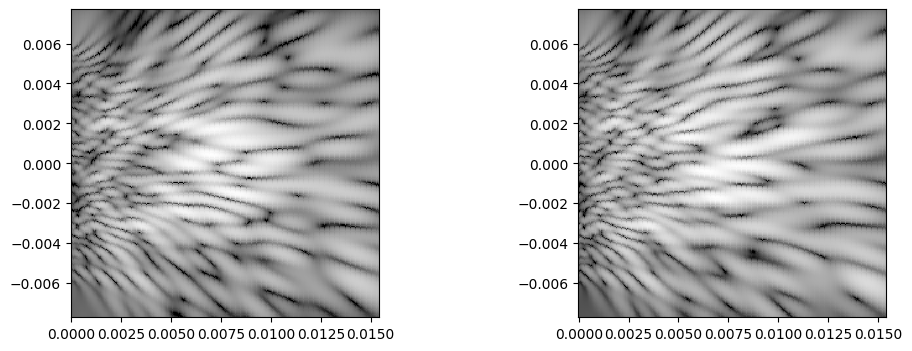

In [32]:
# create the bmodes of the rotated disks
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4))
ax[0].pcolormesh(zi, xi , bmodes[:,:,0],edgecolors='face', cmap = 'gray')
ax[1].pcolormesh(zi, xi , bmodes[:,:,1],edgecolors='face', cmap = 'gray')
[axis.set_aspect('equal') for axis in ax]

Let us now obtain the color doppler images for the synthetic rotating disks

In [33]:
import time

In [34]:
t = time.time()
IQ = None
RFs = None
RFs_tgc = None

# Rotating disk velocity
rotation_frequency = 50 # Hz
w = 2 * np.pi  * rotation_frequency#1 Hz = 2 pi rads
nreps = 5
PRF = 10e3 # at least 200 Hz, for nyquist sampling of rotation
param.PRP = 1 / PRF
param.fs = 4*param.fc
param.attenuation = 0.5

for i in tqdm.tqdm(range(nreps)):
    xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  w * param.PRP)
    width = 10/180*np.pi; # width angle in rad
    txdel = pymust.txdelay(param,0,width) # in s
    #txdel =pymust.txdelayPlane(param, 0)
    RF, RF_spectrum = pymust.simus(xs,zs,RC,txdel,param, options)
    if i ==0:
        IQ = np.zeros([RF.shape[0], RF.shape[1], nreps], dtype = np.complex128)
        RFs = np.zeros([RF.shape[0], RF.shape[1], nreps])
        RFs_tgc = np.zeros([RF.shape[0], RF.shape[1], nreps])
    RFs[:, :, i] = RF
    RFs_tgc[:, :, i], _ = pymust.tgc(RF)
    IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i], param)
print('elapsed time = ', time.time() - t)

100%|██████████| 5/5 [00:02<00:00,  2.07it/s]

elapsed time =  2.416760206222534


In [35]:
# Num points
dx = dz = wavelength / 10
Nx = int(APERTURE_X / dx)
Nz = int(APERTURE_X / dz)
x_extent = np.linspace(-APERTURE_X/2, APERTURE_X/2, Nx)
z_extent = np.linspace(0, APERTURE_X, Nz)
xi,zi = np.meshgrid(x_extent, z_extent)

#x,z = pymust.impolgrid(np.array([Nx, Nz], dtype = np.int64),APERTURE_X, np.pi/2, param)
Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)

for i in tqdm.tqdm(range(nreps)):
    IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
    bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])

100%|██████████| 5/5 [00:00<00:00, 56.74it/s]


In [36]:
doppler_vel, doppler_var = pymust.iq2doppler(IQb,param)
VN = pymust.getNyquistVelocity(param)

In [37]:
from pathlib import Path
dir = Path('./').resolve()
dir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/writting/DataAndSOTA/tcasi_journal')

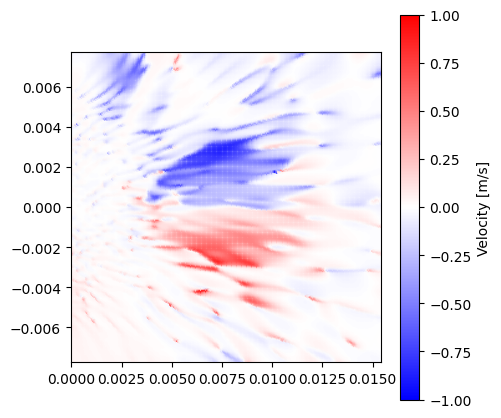

In [38]:
fig, ax = plt.subplots(figsize=(5,5))
cm = ax.pcolormesh(zi, xi, doppler_vel, edgecolors='face', cmap = 'bwr', alpha = doppler_var/np.max(doppler_var), vmin = -1.0, vmax = 1.0)
ax.set_facecolor('white')
ax.set_aspect('equal')
#ec='face' to avoid annoying gridding in pdf
cbar = plt.colorbar(cm)
cbar.ax.set_ylabel('Velocity [m/s]')
fig.savefig(dir / 'example_color_doppler_rotating_disk.pdf', dpi=100)

Text(0, 0.5, 'Variance')

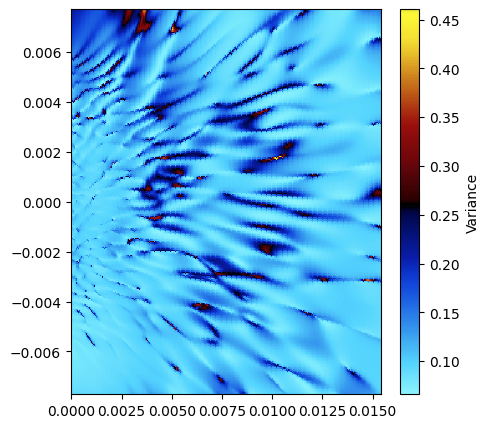

In [39]:
fig, ax = plt.subplots(figsize=(5,5))
cm = ax.pcolormesh(zi, xi, doppler_var, edgecolors='face', cmap = pymust.getDopplerColorMap().cmap, )
ax.set_facecolor('black')
#ec='face' to avoid annoying gridding in pdf
cbar = plt.colorbar(cm)
cbar.ax.set_ylabel('Variance')

## 3.2. Perform Monte Carlo Simulation

In [40]:
from pathlib import Path
dir = Path('./').resolve()
dir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/writting/DataAndSOTA/tcasi_journal')

In [41]:
#from typing import NamedTuple
from dataclasses import dataclass, asdict
@dataclass
class AFEConfig:
  snr: float = np.inf # dB
  hd2: float = np.inf # dB
  hd3: float = np.inf # dB
  gain_range: float = 40 # dB
  psrr: float = np.inf # dB
  gain_err: float = 0.0 #dB
  linear_dynamic_range: float = np.inf #dB
  bw: float = 0.49 # bandwidth multiplifer relative to transducer Fs
  # in this design the bandwidth
  #fs: float = 4.0 # sampling frequency multiplifer relative to transducer Fc
  discrete: bool = False
  gain_steps: int = 1000
  sub_array_size: int = 1
  filter_order: int = 2
  jitter_std: float = 0.0 # s
  settling: float = 10 # Ts / boxcar_tap_settling
  max_input_range: float = 1.0 # 0.45 Volt
  supply: float = 1.8 # V
  
  def __setitem__(self, key, value):
    # Check if the attribute exists to prevent adding random keys
    if hasattr(self, key):
        setattr(self, key, value)
    else:
        raise KeyError(f"'{key}' is not a valid parameter in FilterParams")

  def __getitem__(self, key):
    return getattr(self, key)
  
  def default(self):
    targets = ['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err']
    return {key:asdict(self)[key] for key in targets}

In [42]:
class AFE():
  def __init__(self, param, afe_cfg: AFEConfig):
    self.param = param
    self.cfg = afe_cfg

  def _add_noise(self, r):
    irn_rms = self.cfg.max_input_range / 10**(self.cfg.snr/20)
    noise = np.random.normal(0, irn_rms/np.sqrt(self.cfg.sub_array_size), r.shape)
    return r + noise

  def _add_psrr_induced_noise(self, r):
    psrr_irn = self.cfg.supply / 10**(self.cfg.psrr / 20)
    psrr_irn = psrr_irn / np.sqrt(self.cfg.sub_array_size)
    noise = np.random.normal(0, psrr_irn, r.shape)
    return r + noise

  def _add_distortion(self, r):
    r2 = np.square(r)
    r3 = np.power(r, 3)
    hd2_amplitude = 10 ** (-self.cfg.hd2 / 20)
    hd3_amplitude = 10 ** (-self.cfg.hd3 / 20)

    return r + hd2_amplitude * r2 + hd3_amplitude * r3

  def _filter(self, r):
    # this function applies the zero-order sample and hold filtering within the system
    from scipy.signal import butter, lfilter, firwin
    from scipy.interpolate import interp1d
    #fmax = self.param.fc * (0.5*self.param.bandwidth/100 + 1.0)
    cutoff = self.param.fs * self.cfg.bw
    nyq = self.param.fs * .5
    fc = cutoff / nyq

    num_taps = self.cfg.filter_order # 2 taps
    h = firwin(num_taps, fc, window='boxcar')
    y =  lfilter(h, 1.0, r)
    """
    b, a = butter(
        self.cfg.filter_order,
        cutoff*2*np.pi,
        btype='low', analog=True,
    )
    y =  lfilter(b, a, r)
    """
    # apply clock jitter to the sampled signal
    for k, rf in enumerate(y):
      t = np.arange(0, np.max(rf.shape))/self.param.fs
      t_jittered = t + np.random.normal(0, self.cfg.jitter_std, size=t.shape)
      rf_interp = interp1d(t, rf, kind='linear', fill_value="extrapolate")
      y[k] = rf_interp(t_jittered)


    # apply skew
    y = y * (1 - np.exp(-self.cfg.settling))

    # apply further digital filtering off chip
    #num_taps = 8
    #h = firwin(num_taps, fc, window='nuttall')
    #y = lfilter(h, 1.0, y)

    return y

  def _tgc(self, r):
    y = np.zeros_like(r)
    if self.cfg.discrete:
      tgc_settings = np.linspace(0.0, self.cfg.gain_range, num=int(self.cfg.gain_steps)) + self.cfg.gain_err * (np.random.random(size = int(self.cfg.gain_steps))*2.0 - 1.0)
      seps = int(np.ceil(max(r.shape) / len(tgc_settings)))
      for i in range(len(tgc_settings)):
        y[seps*i:seps*(i+1)] = r[seps*i:seps*(i+1)]*(10**(tgc_settings[i]/20.0))
    else:
      len_rf = max(r.shape)
      av = 10**((self.cfg.gain_range/20)*np.arange(len_rf)/len_rf)
      y = av[:, np.newaxis] * r
    #return y
    #y, _ = must.tgc(r)
    return y

  def __call__(self, r):
    y = self._tgc(self._filter(self._add_distortion(self._add_psrr_induced_noise(self._add_noise(r)))))
    # account for linear dynamic range in the input to output power TF
    #vmin = np.min(y[y!=0])
    #vmax = vmin * 10 ** (self.cfg.linear_dynamic_range / 20)
    #y[y>vmax] = vmax
    return y

In [43]:
from collections import defaultdict

MC_NUM_POINTS = 10
class MonteCarloConfig():
    
    iterations: dict = {
        "snr": 20,
        "hd2": 20,
        "hd3": 20,
        "psrr": 20,
        "gain_err": 20,
        "gain_steps":1
    }
    current_iteration: int = 0
    parameters: dict = {
        "snr": np.linspace(0.0, 100.0, MC_NUM_POINTS)[::-1],
        "hd2": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        "hd3": np.linspace(-60.0, 60.0, MC_NUM_POINTS)[::-1],
        #"linear_dynamic_range": np.linspace(0.0, 100, MC_NUM_POINTS),
        "psrr": np.linspace(0.0, 100, MC_NUM_POINTS)[::-1],
        #"sub_array_size": np.array(list(range(1, COLUMNS+1,))),
        "gain_steps": [1000] + list(range(2, MC_NUM_POINTS+1))[::-1],
        "gain_err": np.linspace(0, 6.0, num=MC_NUM_POINTS)
    }
    results = defaultdict(list)
    

In [44]:
!pip install scikit-image

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [45]:
class ImageMetricEvaluator():
  golden_reference: np.ndarray = None
  anechoic_roi: np.ndarray = None
  hyperechoic_roi: np.ndarray = None
  def __init__(self, golden_reference, anechoic_roi, hyperechoic_roi):
    self.golden_reference = golden_reference
    self.anechoic_roi = anechoic_roi
    self.hyperechoic_roi = hyperechoic_roi
    self.golden_reference8b = (self.golden_reference * 255).astype(np.uint8)
    self.golden_reference8b = self.golden_reference8b.astype(np.float64)

  def _mse(self, I):
    I8b = (I * 255).astype(np.uint8)
    I8b = I8b.astype(np.float64)
    return np.mean((self.golden_reference8b - I8b)**2)

  def _psnr(self, I):
    mse = self._mse(I)
    return 20 * np.log10( 255 / np.sqrt(mse))

  def _ssim(self, I):
    from skimage.metrics import structural_similarity as ssim
    return ssim(self.golden_reference, I, data_range=self.golden_reference.max() - self.golden_reference.min())

  def _gcnr(self, I):
    pass

  def evaluate(self, I):
    return {
        "mse": self._mse(I),
        "psnr": self._psnr(I),
        "ssim": self._ssim(I),
        #"gcnr": self._gcnr(I)
    }

In [46]:
center_frequencies = np.array([2.0, 2.5, 4.0, 6.0])*1e6

In [47]:
mc_cfg = MonteCarloConfig()
print(mc_cfg.parameters)

{'snr': array([100.        ,  88.88888889,  77.77777778,  66.66666667,
        55.55555556,  44.44444444,  33.33333333,  22.22222222,
        11.11111111,   0.        ]), 'hd2': array([ 60.        ,  46.66666667,  33.33333333,  20.        ,
         6.66666667,  -6.66666667, -20.        , -33.33333333,
       -46.66666667, -60.        ]), 'hd3': array([ 60.        ,  46.66666667,  33.33333333,  20.        ,
         6.66666667,  -6.66666667, -20.        , -33.33333333,
       -46.66666667, -60.        ]), 'psrr': array([100.        ,  88.88888889,  77.77777778,  66.66666667,
        55.55555556,  44.44444444,  33.33333333,  22.22222222,
        11.11111111,   0.        ]), 'gain_steps': [1000, 10, 9, 8, 7, 6, 5, 4, 3, 2], 'gain_err': array([0.        , 0.66666667, 1.33333333, 2.        , 2.66666667,
       3.33333333, 4.        , 4.66666667, 5.33333333, 6.        ])}


In [48]:
RUN_MONTE_CARLO_AFE_COLOR_DOPPLER_EVAL = False

if RUN_MONTE_CARLO_AFE_COLOR_DOPPLER_EVAL:
    for f0_setting in center_frequencies:
        mc_cfg.current_iteration = 1
        
        options =  MyOptions()
        options.ParPoolMode = 'thread'
        options.ParPool_NumWorkers = 12
        options.dBThresh = -6
        options.ParPool = os.name == 'posix'
        
        # Setup 2D array
        param = pymust.utils.Param()
        param.fc = f0_setting
        wavelength = c0 / f0_setting
        pitch = wavelength / 2
        param.kerf = 25e-06 # 50 um kerf
        param.pitch = pitch
        param.width = pitch - param.kerf
        param.height = APERTURE_Y - param.kerf
        param.Nelements = COLUMNS

        #BW = 300.0e3
        #param.bandwidth = 100*(BW/ param.fc) # percentage
        param.bandwidth = 70
        param.radius = np.inf
        param.fs = 4*param.fc
        param.attenuation = 0.5
        
        IQ = None
        RFs = None
        RFs_tgc = None

        # Rotating disk velocity
        rotation_frequency = 50 # Hz
        w = 2 * np.pi  * rotation_frequency#1 Hz = 2 pi rads
        nreps = 5
        PRF = 10e3 # at least 200 Hz, for nyquist sampling of rotation
        param.PRP = 1 / PRF
        width = 10/180*np.pi; # width angle in rad
        txdel = pymust.txdelay(param,0,width) # in s
        RFs = None
        RFs_tgc = None
        IQ = None
        for i in tqdm.tqdm(range(nreps)):
            xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  w * param.PRP)
            #txdel =pymust.txdelayPlane(param, 0)
            RF, _ = pymust.simus(xs,zs,RC,txdel,param, options)
            if i ==0:
                IQ = np.zeros([RF.shape[0], RF.shape[1], nreps], dtype = np.complex128)
                RFs = np.zeros([RF.shape[0], RF.shape[1], nreps])
                RFs_tgc = np.zeros([RF.shape[0], RF.shape[1], nreps])
            RFs[:, :, i] = RF
            RFs_tgc[:, :, i], _ = pymust.tgc(RF)
            IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i], param)
        # Num points
        dx = dz = wavelength / 10
        Nx = int(APERTURE_X / dx)
        Nz = int(APERTURE_X / dz)
        x_extent = np.linspace(-APERTURE_X/2, APERTURE_X/2, Nx)
        z_extent = np.linspace(0, APERTURE_X, Nz)
        xi,zi = np.meshgrid(x_extent, z_extent)

        #x,z = pymust.impolgrid(np.array([Nx, Nz], dtype = np.int64),APERTURE_X, np.pi/2, param)
        Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
        IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
        bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)

        for i in tqdm.tqdm(range(nreps)):
            IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
            bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])
        
        doppler_vel, doppler_var = pymust.iq2doppler(IQb,param)
        VN = pymust.getNyquistVelocity(param)
        img_evaluator = ImageMetricEvaluator(doppler_vel, None, None)
        for parameter in tqdm.tqdm(mc_cfg.parameters):
            print(f"Sweeping parameter: {parameter}")
            for idval, val in tqdm.tqdm(enumerate(mc_cfg.parameters[parameter])):
                for iter in tqdm.tqdm(range(mc_cfg.iterations[parameter])):
                    afe_cfg = AFEConfig()
                    afe_cfg.discrete = True
                    if parameter != 'gain_steps':
                        afe_cfg[parameter] = val + 0.05 * np.max(np.abs(mc_cfg.parameters[parameter])) * np.random.randn()
                    else:
                        afe_cfg[parameter] = val
                        
                    afe = AFE(param, afe_cfg)
                    
                    RFs_tgc = np.zeros([RFs.shape[0], RFs.shape[1], nreps])
                    IQ = np.zeros([RFs.shape[0], RFs.shape[1], nreps], dtype = np.complex128)
                    for i in range(nreps):
                        RFs_tgc[:, :, i] = np.clip(afe(RFs[:, :, i] / np.max(np.abs(RFs[:, :, i]))), -1.0, 1.0)
                        #RFs_tgc[:, :, i] = afe(RFs[:, :, i] / np.max(np.abs(RFs[:, :, i])))
                        
                        #RF_tgc.append(afe(r))
                        IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i],param)

                    Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
                    IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
                    #bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)
                    for i in range(nreps):
                        IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
                        #bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])
                    doppler_vel_meas, doppler_var_meas = pymust.iq2doppler(IQb,param)
                    if mc_cfg.current_iteration == 1:
                        #VN = pymust.getNyquistVelocity(param)
                        doppler_vel = doppler_vel_meas.copy()
                        img_evaluator = ImageMetricEvaluator(
                            doppler_vel, None, None)
                        fig, ax = plt.subplots(figsize=(5,5))
                        cm = ax.pcolormesh(
                            zi, xi, doppler_vel, edgecolors='face', 
                            cmap = pymust.getDopplerColorMap().cmap, 
                            alpha = doppler_var/np.max(doppler_var), vmin = -1.0, vmax = 1.0)
                        ax.set_facecolor('black')
                        ax.set_aspect('equal')
                        ax.set_yticks([]); ax.set_xticks([])
                        #ax.set_yticks([xi[0, 0], 0.0, xi[0, -1]])
                        #ax.set_xticks([zi[0, 0], zi[0, -1]])
                        #ec='face' to avoid annoying gridding in pdf
                        cbar = plt.colorbar(cm)
                        cbar.ax.set_ylabel('Velocity [m/s]')
                        fig.tight_layout()
                        fig.savefig(dir / f'color_doppler_ref_f0_mhz_{f0/1e6}.pdf', dpi=300)
                        plt.show()
                    # Measure
                    results_img_eval_raw = img_evaluator.evaluate(doppler_vel_meas)
                    results_img_eval = {k:v for k,v in results_img_eval_raw.items() if k != "gcnr"}
                    #results_img_eval['a-gcnr'], results_img_eval['h-gcnr'] = results_img_eval_raw['gcnr']
                    results_db_row = {'f0_mhz': f0_setting/1e6}
                    results_db_row.update(afe_cfg.default())
                    results_db_row.update(results_img_eval)
                    if mc_cfg.current_iteration == 1:
                        with open(dir / 'mc_results_afe_eval_color_doppler.csv', 'a') as fp:
                            fp.write(','.join([k for k in results_db_row.keys()])+'\n')
                    #print(results_db_row)
                    with open(dir / 'mc_results_afe_eval_color_doppler.csv', 'a') as fp:
                        fp.write(','.join([str(k) for k in results_db_row.values()])+'\n')
                    mc_cfg.current_iteration += 1

## 3.3. Color Doppler Image Quality vs. Analog Frontend Non-idealities

In [49]:
import scienceplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.style.use(['science', 'nature'])

In [50]:
from pathlib import Path
dir = Path('./').resolve()
dir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/writting/DataAndSOTA/tcasi_journal')

In [51]:
mcdf = pd.read_csv(dir / 'mc_results_afe_eval_color_doppler.csv')
print(len(mcdf))
mcdf.head()

4040


,f0_mhz,snr,hd2,hd3,gain_steps,psrr,gain_err,mse,psnr,ssim
0,2.0,109.076253,inf,inf,1000,inf,0.0,0.000000,inf,1.0
1,2.0,105.516360,inf,inf,1000,inf,0.0,3.284841,42.965660,1.0
2,2.0,105.553043,inf,inf,1000,inf,0.0,4.926845,41.205114,1.0
3,2.0,100.672108,inf,inf,1000,inf,0.0,3.285372,42.964959,1.0
4,2.0,100.294501,inf,inf,1000,inf,0.0,1.643620,45.972789,1.0


In [52]:
xvars = list(mcdf.columns[1:7])
yvars = list(mcdf.columns[7:])
xvars, yvars

(['snr', 'hd2', 'hd3', 'gain_steps', 'psrr', 'gain_err'],
 ['mse', 'psnr', 'ssim'])

In [53]:
batch_size = 5
group_id = np.arange(len(mcdf)) // batch_size

for xvar in xvars:
    mcdf['mean_' + xvar] = mcdf.groupby(group_id)[xvar].transform('mean')

mcdf.head()

,f0_mhz,snr,hd2,hd3,gain_steps,psrr,gain_err,mse,psnr,ssim,mean_snr,mean_hd2,mean_hd3,mean_gain_steps,mean_psrr,mean_gain_err
0,2.0,109.076253,inf,inf,1000,inf,0.0,0.000000,inf,1.0,104.222453,inf,inf,1000.0,inf,0.0
1,2.0,105.516360,inf,inf,1000,inf,0.0,3.284841,42.965660,1.0,104.222453,inf,inf,1000.0,inf,0.0
2,2.0,105.553043,inf,inf,1000,inf,0.0,4.926845,41.205114,1.0,104.222453,inf,inf,1000.0,inf,0.0
3,2.0,100.672108,inf,inf,1000,inf,0.0,3.285372,42.964959,1.0,104.222453,inf,inf,1000.0,inf,0.0
4,2.0,100.294501,inf,inf,1000,inf,0.0,1.643620,45.972789,1.0,104.222453,inf,inf,1000.0,inf,0.0


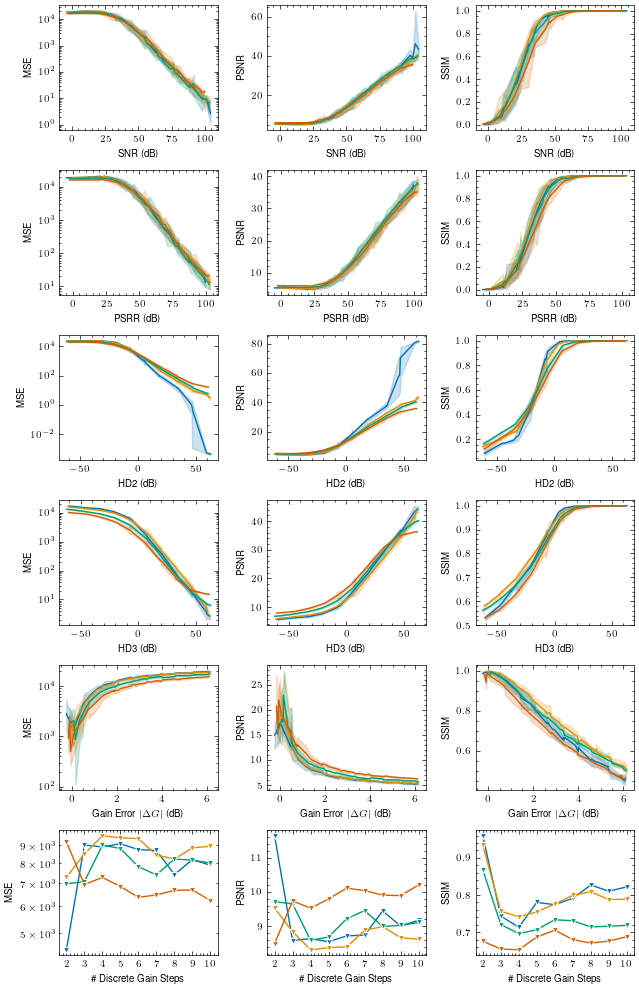

In [54]:
fig, ax = plt.subplots(len(xvars),len(yvars), figsize=(6.5,10))

letters = [c for c in range(ord('a'),ord('z')+1)]

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['snr']<np.inf], x='mean_snr', y=yvar, ax=ax[0, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[0, yvars.index(yvar)].set_yscale('log')
    ax[0, yvars.index(yvar)].set_xlabel('SNR (dB)')
    ax[0, yvars.index(yvar)].set_ylabel(yvar.upper())
    
for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['psrr']<np.inf], x='mean_psrr', y=yvar, ax=ax[1, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[1, yvars.index(yvar)].set_yscale('log')
    ax[1, yvars.index(yvar)].set_xlabel('PSRR (dB)')
    ax[1, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['hd2']<np.inf], x='mean_hd2', y=yvar, ax=ax[2, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[2, yvars.index(yvar)].set_yscale('log')
    ax[2, yvars.index(yvar)].set_xlabel('HD2 (dB)')
    ax[2, yvars.index(yvar)].set_ylabel(yvar.upper())
    
for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['hd3']<np.inf], x='mean_hd3', y=yvar, ax=ax[3, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[3, yvars.index(yvar)].set_yscale('log')
    ax[3, yvars.index(yvar)].set_xlabel('HD3 (dB)')
    ax[3, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data=mcdf[mcdf['gain_err']!=0.0], x='mean_gain_err', y=yvar, ax=ax[4, yvars.index(yvar)], hue='f0_mhz',legend=False,palette='colorblind')
    if yvar not in ['ssim', 'psnr']:
        ax[4, yvars.index(yvar)].set_yscale('log')
    ax[4, yvars.index(yvar)].set_xlabel('Gain Error $|\Delta G|$ (dB)')
    ax[4, yvars.index(yvar)].set_ylabel(yvar.upper())

for i, yvar in enumerate(yvars):
    sns.lineplot(
        data = mcdf[mcdf['gain_steps']>=2][mcdf['gain_steps']<=10], 
        x='gain_steps', 
        y=yvar, 
        ax=ax[5, yvars.index(yvar)], 
        hue='f0_mhz', 
        legend=False,
        palette='colorblind',
        marker='v',
        markersize=5)
    if yvar not in ['ssim', 'psnr']:
        ax[5, yvars.index(yvar)].set_yscale('log')
    ax[5, yvars.index(yvar)].set_xlabel('\# Discrete Gain Steps')
    ax[5, yvars.index(yvar)].set_ylabel(yvar.upper())
    ax[5, yvars.index(yvar)].set_xticks(list(range(2,11)))

fig.tight_layout()
fig.savefig(dir/'mc_color_doppler_results.pdf', dpi=300)

In [55]:
import pymust
import numpy as np 
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import tqdm
plt.style.use(['science', 'nature'])

In [56]:
from pathlib import Path
dir = Path('./').resolve()
dir

PosixPath('/Users/dasdias/Documents/PhD-NOVA/writting/DataAndSOTA/tcasi_journal')

100%|██████████| 5/5 [00:00<00:00, 206.17it/s]
0it [00:00, ?it/s]

Sweeping parameter: snr


4it [00:02,  1.67it/s]
1it [00:02,  2.39s/it]

Sweeping parameter: hd3


4it [00:01,  2.40it/s]
2it [00:04,  1.97s/it]

...

4it [00:17,  4.45s/it]
2it [00:35, 17.68s/it]

Sweeping parameter: gain_steps


4it [00:16,  4.10s/it]
3it [00:51, 17.09s/it]

Sweeping parameter: gain_err


4it [00:15,  3.96s/it]
4it [01:07, 16.88s/it]


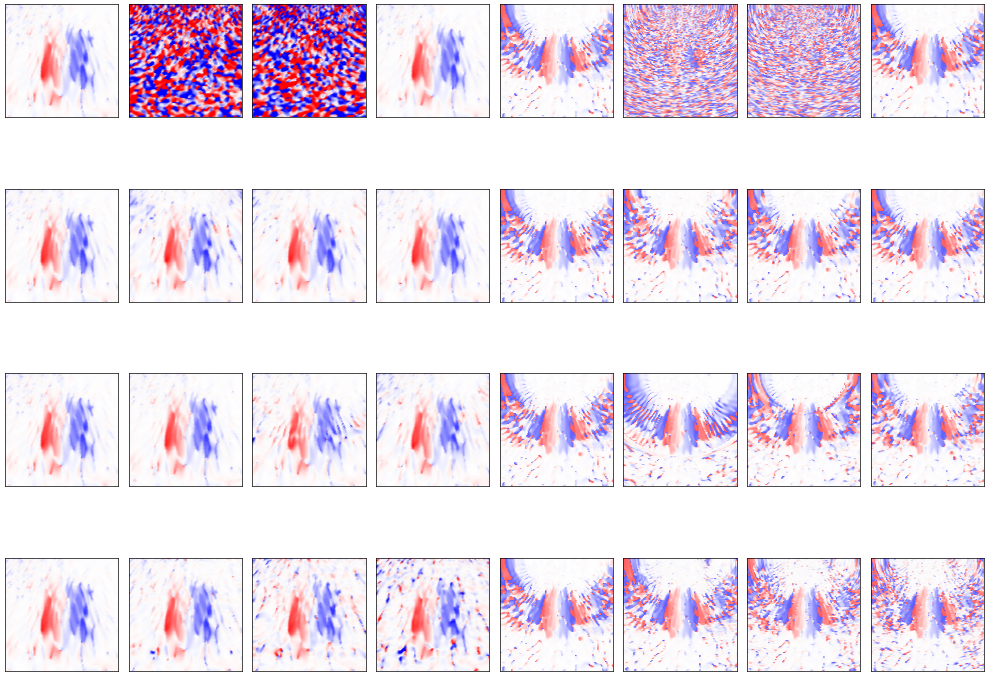

In [66]:


img_sweep_config = {
    'snr': np.array([np.inf, -6, 0, 60]),
    'hd3': np.array([np.inf, -6, 0, 30]),
    'gain_steps': np.array([1000, 2, 4, 10]),
    'gain_err': np.array([0, 3, 6, 9]),
}
center_frequencies = [2.0e6, 6.0e6]
fig, ax = plt.subplots(4, 8, figsize=(10,8))
RUN_MONTE_CARLO_IMG_SWEEP_COLOR_DOPPLER = True

class MyOptions(pymust.utils.Options):
    def copy(self):
        p = MyOptions()
        for k in self.keys():
            p[k] = self[k]
        return p

def rotatePoints(x, y, x0, y0, theta):
    """
    Rotate points (x,y) around (x0,y0) by theta radians
    """
    x = x - x0
    y = y - y0
    x1 = x * np.cos(theta) - y * np.sin(theta) + x0
    y1 = x * np.sin(theta) + y * np.cos(theta) + y0
    return x1, y1

if RUN_MONTE_CARLO_IMG_SWEEP_COLOR_DOPPLER:
    for fidx, f0_setting in enumerate(center_frequencies):
        
        options =  MyOptions()
        options.ParPoolMode = 'thread'
        options.ParPool_NumWorkers = 12
        options.dBThresh = -6
        options.ParPool = os.name == 'posix'
        c0 = 1540 # m/s
        wavelength = c0 / f0_setting
        pitch = wavelength / 2

        max_pitch = 385e-6 # pitch of 2MHz array
        COLUMNS = 40
        ROWS = 40
        kerf = 25e-6
        APERTURE_X = COLUMNS * max_pitch - kerf
        APERTURE_Y = ROWS * max_pitch - kerf
        depth = 5e-2
        # Setup 2D array
        param = pymust.utils.Param()
        param.fc = f0_setting
        wavelength = c0 / f0_setting
        pitch = wavelength / 2
        param.kerf = 25e-06 # 50 um kerf
        param.pitch = pitch
        param.width = pitch - param.kerf
        param.height = APERTURE_Y - param.kerf
        param.Nelements = COLUMNS

        #BW = 300.0e3
        #param.bandwidth = 100*(BW/ param.fc) # percentage
        param.bandwidth = 70
        param.radius = np.inf
        param.fs = 4*param.fc
        param.attenuation = 0.5
        
        IQ = None
        RFs = None
        RFs_tgc = None
        
        small_test = True # Turn it to true if your computer has problems computing
        #param = pymust.getparam('L11-5v')
        param.TXnow = 10

        nPoints = 500000 if not small_test else 50000
        xs = np.random.rand(1,nPoints)*APERTURE_X - APERTURE_X / 2
        zs = np.random.rand(1,nPoints)*APERTURE_X

        centerDisk = APERTURE_X / 2
        idx = np.hypot(xs,zs-centerDisk)<3e-3 # First disk
        #idx2 = np.hypot(xs,zs-.035)< 5e-3 # Second disk, smaller with high intensity

        RC = np.random.rand(*xs.shape)  # reflection coefficients

        # Add reflectiion to both spheres
        RC[idx] += .5

        # Rotating disk velocity
        rotation_frequency = 50 # Hz
        w = 2 * np.pi  * rotation_frequency#1 Hz = 2 pi rads
        nreps = 5
        PRF = 10e3 # at least 200 Hz, for nyquist sampling of rotation
        param.PRP = 1 / PRF
        width = 10/180*np.pi; # width angle in rad
        txdel = pymust.txdelay(param,0,width) # in s
        RFs = None
        RFs_tgc = None
        IQ = None
        for i in tqdm.tqdm(range(nreps)):
            xs[idx], zs[idx] = rotatePoints(xs[idx], zs[idx], 0, centerDisk,  w * param.PRP)
            #txdel =pymust.txdelayPlane(param, 0)
            RF, _ = pymust.simus(xs,zs,RC,txdel,param, options)
            if i ==0:
                IQ = np.zeros([RF.shape[0], RF.shape[1], nreps], dtype = np.complex128)
                RFs = np.zeros([RF.shape[0], RF.shape[1], nreps])
                RFs_tgc = np.zeros([RF.shape[0], RF.shape[1], nreps])
            RFs[:, :, i] = RF
            RFs_tgc[:, :, i], _ = pymust.tgc(RF)
            IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i], param)
        # Num points
        dx = dz = wavelength / 10
        Nx = int(APERTURE_X / dx)
        Nz = int(APERTURE_X / dz)
        x_extent = np.linspace(-APERTURE_X/2, APERTURE_X/2, Nx)
        z_extent = np.linspace(0, APERTURE_X, Nz)
        xi,zi = np.meshgrid(x_extent, z_extent)

        #x,z = pymust.impolgrid(np.array([Nx, Nz], dtype = np.int64),APERTURE_X, np.pi/2, param)
        Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
        IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
        bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)

        for i in tqdm.tqdm(range(nreps)):
            IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
            bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])
        
        doppler_vel, doppler_var = pymust.iq2doppler(IQb,param)
        VN = pymust.getNyquistVelocity(param)
        for paridx, parameter in tqdm.tqdm(enumerate(img_sweep_config.keys())):
            print(f"Sweeping parameter: {parameter}")
            for idval, val in tqdm.tqdm(enumerate(img_sweep_config[parameter])):
                afe_cfg = AFEConfig()
                afe_cfg.discrete = True
                if parameter != 'gain_steps':
                    afe_cfg[parameter] = val + 0.05 * np.max(np.abs(mc_cfg.parameters[parameter])) * np.random.randn()
                else:
                    afe_cfg[parameter] = val
                    
                afe = AFE(param, afe_cfg)
                
                RFs_tgc = np.zeros([RFs.shape[0], RFs.shape[1], nreps])
                IQ = np.zeros([RFs.shape[0], RFs.shape[1], nreps], dtype = np.complex128)
                for i in range(nreps):
                    RFs_tgc[:, :, i] = np.clip(afe(RFs[:, :, i] / np.max(np.abs(RFs[:, :, i]))), -1.0, 1.0)
                    #RFs_tgc[:, :, i] = afe(RFs[:, :, i] / np.max(np.abs(RFs[:, :, i])))
                    
                    #RF_tgc.append(afe(r))
                    IQ[:, :, i] = pymust.rf2iq(RFs_tgc[:, :, i],param)
                Mdas = pymust.dasmtx(IQ[:,:,0],xi,zi,param)
                IQb = np.zeros((xi.shape[0], xi.shape[1],nreps), dtype = np.complex128)
                #bmodes = np.zeros((xi.shape[0], xi.shape[1], nreps), dtype = np.float32)
                for i in range(nreps):
                    IQb[:, :, i] = (Mdas@IQ[:,:,i].flatten(order = 'F')).reshape(xi.shape, order = 'F')
                    #bmodes[:,:, i] = pymust.bmode(IQb[:,:,i])
                doppler_vel_meas, doppler_var_meas = pymust.iq2doppler(IQb,param)
                cm = ax[paridx, fidx*4 + idval].pcolormesh(
                    xi, zi[::-1], doppler_vel_meas, edgecolors='face', 
                    cmap = 'bwr', #cmap = pymust.getDopplerColorMap().cmap, 
                    alpha = doppler_var/np.max(doppler_var), vmin = -1.0, vmax = 1.0)
                ax[paridx, fidx*4 + idval].set_facecolor('white')
                ax[paridx, fidx*4 + idval].set_aspect('equal')
                ax[paridx, fidx*4 + idval].set_yticks([]); ax[paridx, fidx*4 + idval].set_xticks([])
                #cbar = plt.colorbar(cm, ax=ax[paridx, fidx*4 + idval], fraction=0.046, pad=0.04)
                #cbar.ax.set_ylabel('Velocity [m/s]')
#
fig.tight_layout()
fig.savefig(dir / "color_doppler_afe_eval_example_res.pdf", dpi=10)


In [67]:
fig.tight_layout()
fig.savefig(dir / "color_doppler_afe_eval_example_res.png", dpi=300, transparent=True,bbox_inches='tight')